In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')


In [2]:
# pre-processing data

est = train.describe()

# print(est)

# print(train.info())

#vereificar valores nulos
#print(train.isnull().sum())

#mapear colunas
col = pd.Series(list(train.columns))
#print(col)

X_train = train.drop(columns=['PassengerId', 'Survived'], axis=1)

X_test = test.drop(columns=['PassengerId'], axis=1)




In [3]:
train.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [4]:
#criar features
def criar_features(x):
    subsFemale = {'male': 0, 'female': 1}
    x['isFemale'] = x['Sex'].replace(subsFemale)

    x['Age'].fillna(x['Age'].mean(), inplace=True)
    x['Fare'].fillna(x['Fare'].mean(), inplace=True)  
    x['Embarked'].fillna('S', inplace=True) 

    subsPort = {'S': 0, 'C': 1, 'Q': 2}
    x['Port'] = x['Embarked'].replace(subsPort)

    x['isChild'] = np.where(x['Age'] < 12, 1, 0)

    # Criando feature de quem pagou mais caro sobreviveu
    x['FareBin'] = pd.qcut(x['Fare'], 4, labels=False)

    #criando feature de quem embarcou no porto C sobreviveu
    x['PortC'] = np.where(x['Port'] == 1, 1, 0)

    #criando feature de quem nao tinha parente sobreviveu
    x['NoRelatives'] = np.where((x['SibSp'] + x['Parch']) == 0, 1, 0)   

    

    return x


In [5]:
# Selecionar features

X_train = criar_features(X_train)
X_test = criar_features(X_test) 

features = [ 'Age', 'SibSp',
       'Parch', 'Fare', 'isFemale', 'Port', 'isChild', 'FareBin', 'PortC',
       'NoRelatives']

X_train = X_train[features]
X_test = X_test[features]

y_train = train['Survived']


C:\Users\uni34786\AppData\Local\Temp\ipykernel_29712\2055684526.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x['isFemale'] = x['Sex'].replace(subsFemale)
C:\Users\uni34786\AppData\Local\Temp\ipykernel_29712\2055684526.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Age'].fillna(x['Age'

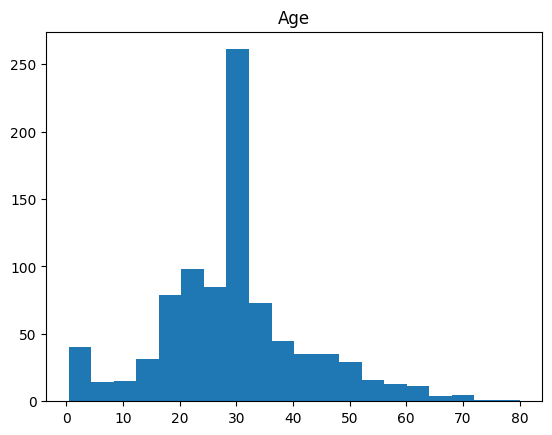

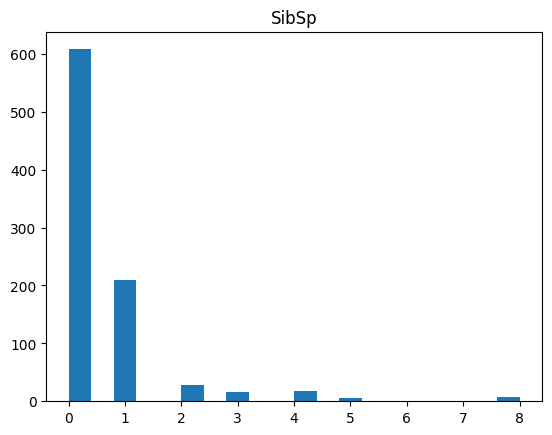

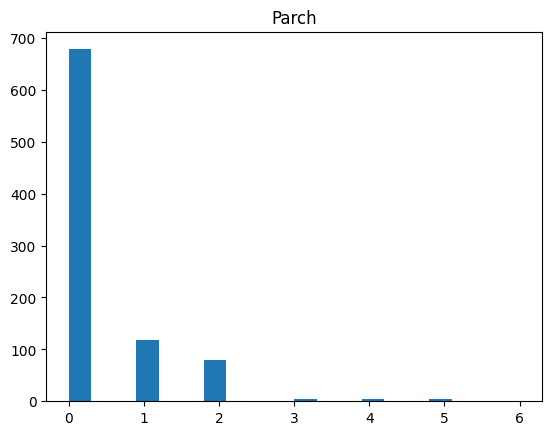

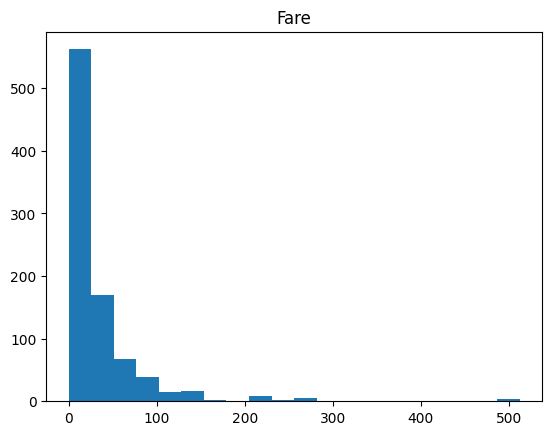

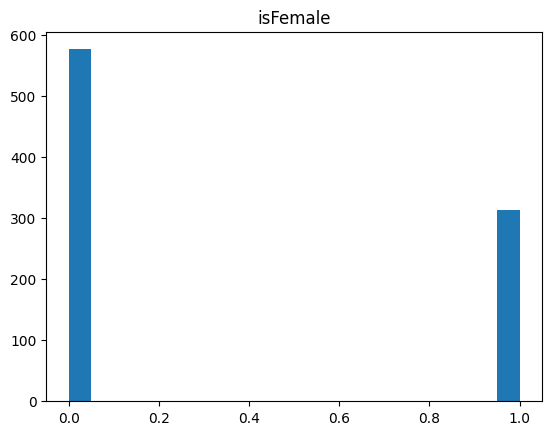

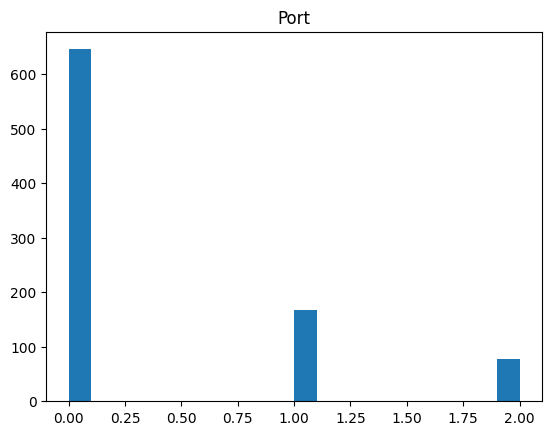

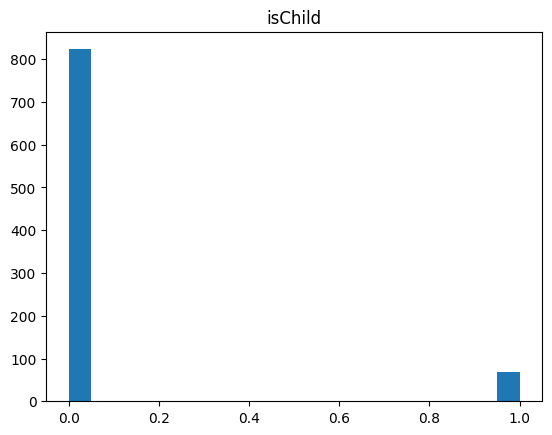

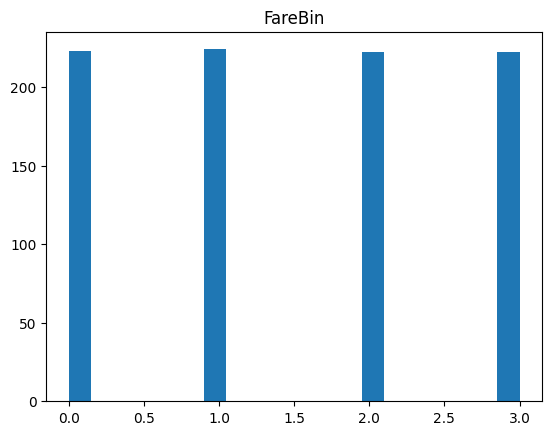

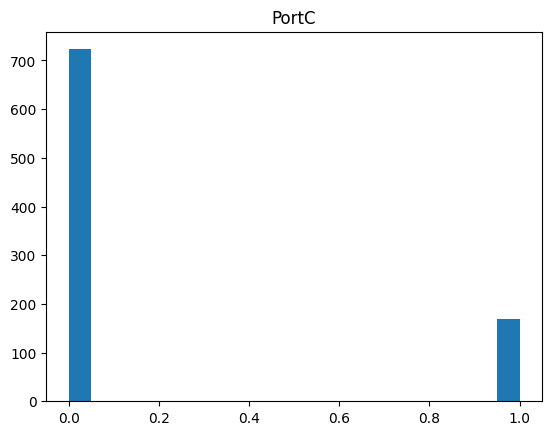

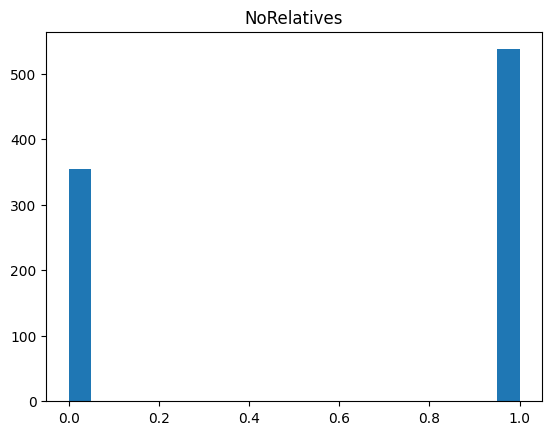

In [6]:
import matplotlib.pyplot as plt

for i in X_train.columns:
    plt.figure()
    plt.hist(X_train[i], bins=20)
    plt.title(i)
    plt.show()

In [7]:
#Padronizar dados
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
%pip install scikit-learn

#Modelo e validação

#logistic regression
from sklearn.linear_model import LogisticRegression


# print(X_train.head())
# print(y_train.head())

model_lr = LogisticRegression(random_state=0)

score = cross_val_score(model_lr, X_train, y_train, cv=10)

print("Logistic Regression Accuracy: %0.4f" % (np.mean(score)))
# Logistic Regression Accuracy: 0.7890 - USANDO MEDIANA PARA AGE E FARE
# Logistic Regression Accuracy: 0.7890 - USANDO MEDIA PARA AGE E FARE


Note: you may need to restart the kernel to use updated packages.
Logistic Regression Accuracy: 0.7946


In [9]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB  

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)  

score = cross_val_score(model_nb, X_train, y_train, cv=10)
print("Gaussian Naive Bayes Accuracy: %0.4f" % (np.mean(score)))



Gaussian Naive Bayes Accuracy: 0.7689


In [10]:
# KNN para classificação
from sklearn.neighbors import KNeighborsClassifier  

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train) 

score = cross_val_score(model_knn, X_train, y_train, cv=10)
print("KNN Accuracy: %0.4f" % (np.mean(score)))

KNN Accuracy: 0.8025


In [11]:
#SVM para classificação
from sklearn.svm import SVC
model_svm = SVC(C=1, gamma='auto')
model_svm.fit(X_train, y_train) 

score = cross_val_score(model_svm, X_train, y_train, cv=10)
print("SVM Accuracy: %0.4f" % (np.mean(score)))

SVM Accuracy: 0.8216


In [12]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=1, min_samples_split=5, random_state=0)
model_tree.fit(X_train, y_train)

score = cross_val_score(model_tree, X_train, y_train, cv=10)
print("Decision Tree Accuracy: %0.4f" % (np.mean(score))) 

Decision Tree Accuracy: 0.8058


In [13]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
model_forest = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, min_samples_leaf=1, min_samples_split=3, random_state=0)
model_forest.fit(X_train, y_train)

score = cross_val_score(model_forest, X_train, y_train, cv=10)
print("Random Forest Accuracy: %0.4f" % (np.mean(score)))


Random Forest Accuracy: 0.8227


In [14]:
# Modelo final
model_forest.fit(X_train, y_train)
y_pred = model_forest.predict(X_train)
predictions_test = model_forest.predict(X_test)

score = model_forest.score(X_train, y_train)
print("Score: %0.4f" % (score))

submission = pd.DataFrame(test['PassengerId'])
submission['Survived'] = predictions_test    

submission.to_csv('data/123103_submission_model_forest.csv', index=False)


Score: 0.8339


In [15]:
# CNN 
